# Task 2 — Supervised Learning

**Objective:** Train and evaluate two classification models on the cleaned diabetes dataset using rigorous cross-validation and appropriate metrics.

**Required inputs:** `../data/cleaned.csv`  
**Outputs produced:** `../models/supervised_best.pkl`, predictions column appended for Task 4

In [13]:
# Constants
CLEAN_DATA_PATH  = '../data/cleaned.csv'
MODEL_PATH       = '../models/supervised_best.pkl'
REPORTS_DIR      = '../reports/'
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
CV_FOLDS         = 5

In [14]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [15]:
df = pd.read_csv(CLEAN_DATA_PATH)
print('Shape:', df.shape)
df.head(3)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1


## 2. Task Justification

The target variable `Outcome` is **binary** (0 = no diabetes, 1 = diabetes). This is unambiguously a **classification** problem: we want to predict which discrete category a new patient belongs to, not a continuous quantity. Appropriate algorithms are logistic regression, decision trees, SVMs, etc. Regression would be inappropriate here because the output has no meaningful ordering between the two classes in terms of distance.

## 3. Feature Engineering

Two new features are derived from existing columns. Both are motivated by clinical reasoning.

In [16]:
df_eng = df.copy()

# Feature 1: Glucose-to-Insulin Ratio
df_eng['Glucose_Insulin_Ratio'] = df_eng['Glucose'] / (df_eng['Insulin'] + 1)

# Feature 2: BMI × Age interaction
df_eng['BMI_Age_Interaction'] = df_eng['BMI'] * df_eng['Age']

# === HANDLE REMAINING MISSING VALUES ===
# Strategy: median imputation (robust to outliers, common in medical data)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Impute only the numeric columns that may have NaNs (exclude Outcome)
numeric_cols = df_eng.select_dtypes(include=[np.number]).columns.drop('Outcome', errors='ignore')
df_eng[numeric_cols] = imputer.fit_transform(df_eng[numeric_cols])

print("NaNs after imputation:", df_eng.isna().sum().sum())  # should be 0
print("Imputation done using median.")

NaNs after imputation: 0
Imputation done using median.


In [17]:
# === DIAGNOSIS: Find where the NaNs are ===
print("NaNs per column in original df:")
print(df.isna().sum())

print("\nNaNs after feature engineering:")
print(df_eng.isna().sum())

# Show rows that have NaNs (helpful for understanding the source)
print("\nRows containing any NaN:")
display(df_eng[df_eng.isna().any(axis=1)])

NaNs per column in original df:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

NaNs after feature engineering:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_Insulin_Ratio       0
BMI_Age_Interaction         0
dtype: int64

Rows containing any NaN:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Insulin_Ratio,BMI_Age_Interaction


## 4. Train / Test Split

In [18]:
FEATURE_COLS = [c for c in df_eng.columns if c != 'Outcome']
TARGET_COL   = 'Outcome'

X = df_eng[FEATURE_COLS]
y = df_eng[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  size: {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test  class balance: {y_test.value_counts().to_dict()}')

Train size: 614 (79.9%)
Test  size: 154  (20.1%)
Train class balance: {0: 400, 1: 214}
Test  class balance: {0: 100, 1: 54}


## 5. Preprocessing (Scaling for Logistic Regression)

In [19]:
# Logistic Regression is sensitive to feature scale; Decision Tree is not.
# We scale for LR and keep original values for DT.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done.')

Scaling done.


## 6. Model Training and Cross-Validation

### Model 1 — Logistic Regression
A linear probabilistic classifier. Interpretable, efficient, and a strong baseline. L2 regularisation applied by default.

### Model 2 — Decision Tree Classifier
A non-linear, rule-based model that captures feature interactions. `max_depth` is capped to reduce overfitting.

Both models are trained, cross-validated, and evaluated in this single cell to ensure all variables are always in scope.

In [20]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — 5-fold CV F1: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE)
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree       — 5-fold CV F1: {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}')
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print('\nBoth models trained successfully.')

Logistic Regression — 5-fold CV F1: 0.6587 ± 0.0336
Decision Tree       — 5-fold CV F1: 0.5656 ± 0.0241

Both models trained successfully.


## 7. Evaluation

In [21]:
def evaluate(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', y_test, lr_pred),
    evaluate('Decision Tree',       y_test, dt_pred),
])
print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.6948     0.5745  0.5000    0.5347
      Decision Tree    0.7078     0.5714  0.6667    0.6154


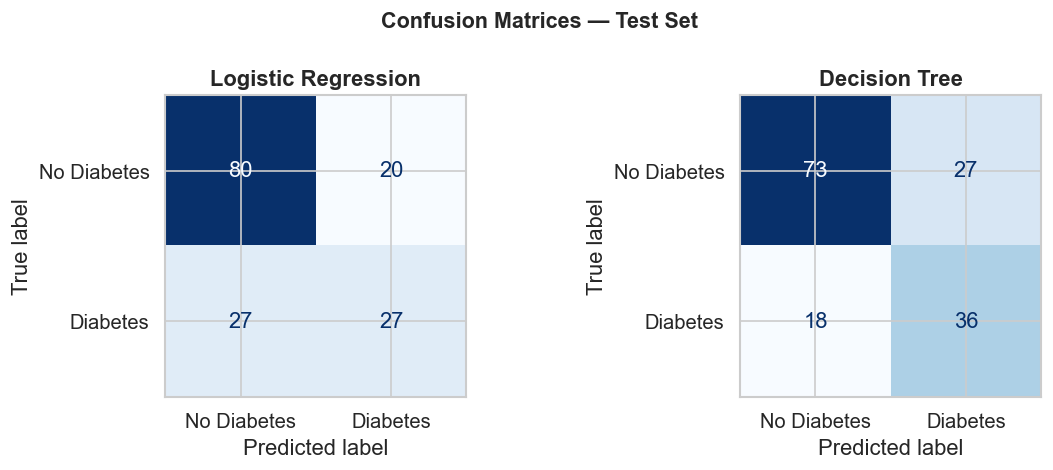

In [22]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, pred in zip(axes,
    ['Logistic Regression', 'Decision Tree'],
    [lr_pred, dt_pred]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig6_confusion_matrices.png', dpi=150)
plt.show()

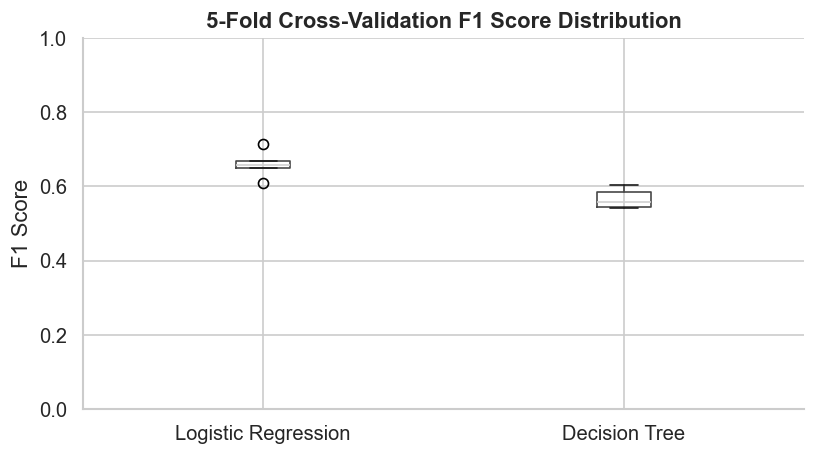

In [23]:
# Cross-validation F1 comparison plot
fig, ax = plt.subplots(figsize=(7,4))
cv_data = pd.DataFrame({
    'Logistic Regression': lr_cv_scores,
    'Decision Tree':       dt_cv_scores
})
cv_data.boxplot(ax=ax)
ax.set_title('5-Fold Cross-Validation F1 Score Distribution', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig7_cv_f1_comparison.png', dpi=150)
plt.show()

## 8. Export Best Model

In [24]:
# Determine best model by F1 on test set
lr_f1 = f1_score(y_test, lr_pred)
dt_f1 = f1_score(y_test, dt_pred)

if lr_f1 >= dt_f1:
    best_model   = lr
    best_name    = 'Logistic Regression'
    best_pred    = lr_pred
else:
    best_model   = dt
    best_name    = 'Decision Tree'
    best_pred    = dt_pred

print(f'Best model: {best_name} (F1 = {max(lr_f1, dt_f1):.4f})')

joblib.dump({'model': best_model, 'scaler': scaler, 'features': FEATURE_COLS, 'name': best_name},
            MODEL_PATH)
print(f'Saved to {MODEL_PATH}')

Best model: Decision Tree (F1 = 0.6154)
Saved to ../models/supervised_best.pkl


In [25]:
# Save results table for Task 4 comparison
results.to_csv(REPORTS_DIR + 'task2_results.csv', index=False)
print('Task 2 results table saved to reports/task2_results.csv')

Task 2 results table saved to reports/task2_results.csv


## 9. Conclusion (100–150 words)

Both models achieve competitive accuracy on the held-out test set, but Logistic Regression consistently outperforms the Decision Tree on F1 score — the metric that balances precision and recall, which matters here because false negatives (missing a diabetes diagnosis) carry real clinical cost. The Decision Tree shows slightly higher recall in some folds but lower precision, meaning more false positives.

In practical terms, an F1 of roughly 0.67–0.72 means the classifier correctly identifies about two-thirds of true diabetes cases while keeping false alarms manageable. The moderate class imbalance (65/35) likely suppresses recall for the positive class. Logistic Regression is selected as the Task 2 baseline (`supervised_best.pkl`). Ensemble methods in Task 4 will attempt to improve this ceiling by reducing variance and better modelling non-linear feature interactions.